# 🧠 Lab 1 — Vector Database with Weaviate

## What is a Vector Database?

A **vector database** stores data as high-dimensional vectors (embeddings) and allows **semantic search** — finding similar content by meaning, not just keywords.

```
Text → Embedding Model → Vector [0.12, 0.45, -0.33, ...]
                                        ↓
                              Stored in Weaviate
                                        ↓
Query → Embed → Compare vectors → Return most similar
```

## Why Weaviate?
- ✅ Free cloud sandbox
- ✅ Fast vector search (HNSW index)
- ✅ Supports custom embeddings (bring your own)
- ✅ Simple Python client v4

## 1️⃣ Install & Import

In [1]:
import weaviate
import weaviate.classes as wvc
import ollama
import os
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from IPython.display import display

load_dotenv()
print('✅ Imports OK')

✅ Imports OK


## 2️⃣ Connect to Weaviate Cloud

We connect using our **API key** from the Weaviate Cloud console.

In [2]:
client = weaviate.connect_to_weaviate_cloud(
    cluster_url=os.getenv('WEAVIATE_URL'),
    auth_credentials=weaviate.auth.AuthApiKey(os.getenv('WEAVIATE_API_KEY'))
)

print('✅ Connected:', client.is_ready())

✅ Connected: True


## 3️⃣ Create a Collection (Schema)

A **collection** in Weaviate is like a table in SQL.
We define:
- Properties (fields)
- Vector index type (HNSW — fast approximate nearest neighbor)
- We bring our **own embeddings** (no built-in vectorizer)

In [7]:
COLLECTION_NAME = 'MedicalChunks'

# Delete if already exists (clean start)
if client.collections.exists(COLLECTION_NAME):
    client.collections.delete(COLLECTION_NAME)
    print(f'🗑️  Deleted existing collection: {COLLECTION_NAME}')

# Create collection
collection = client.collections.create(
    name=COLLECTION_NAME,
    vectorizer_config=wvc.config.Configure.Vectorizer.none(),
    properties=[
        wvc.config.Property(name='text',     data_type=wvc.config.DataType.TEXT),
        wvc.config.Property(name='page',     data_type=wvc.config.DataType.INT),
        wvc.config.Property(name='chunk_id', data_type=wvc.config.DataType.INT),
    ]
)
print(f'✅ Collection created: {COLLECTION_NAME}')

✅ Collection created: MedicalChunks


## 4️⃣ Embed Text with Ollama

We use **nomic-embed-text** running locally via Ollama.
This converts text into a **768-dimensional vector**.

In [8]:
def embed(text: str) -> list[float]:
    """
    Embed a single text using Ollama nomic-embed-text.
    Returns a list of floats (the embedding vector).
    """
    response = ollama.embeddings(model='nomic-embed-text', prompt=text)
    return response['embedding']

# Test
test_vec = embed('The heart pumps blood through the body.')
print(f'✅ Embedding dim: {len(test_vec)}')
print(f'   First 5 values: {test_vec[:5]}')

✅ Embedding dim: 768
   First 5 values: [1.663796305656433, 1.9270304441452026, -3.9427545070648193, 0.44070005416870117, 0.749862790107727]


## 5️⃣ Insert Sample Data

We insert a few sample medical sentences to test the vector DB.
In **Lab 3**, we'll insert real chunks from our medical book.

In [9]:
sample_data = [
    {'text': 'The heart is a muscular organ that pumps blood throughout the body.', 'page': 1, 'chunk_id': 0},
    {'text': 'The skin is the largest organ of the human body and protects against infection.', 'page': 2, 'chunk_id': 1},
    {'text': 'Neurons transmit electrical signals through the nervous system.', 'page': 3, 'chunk_id': 2},
    {'text': 'The lungs exchange oxygen and carbon dioxide during breathing.', 'page': 4, 'chunk_id': 3},
    {'text': 'Bones provide structural support and protect internal organs.', 'page': 5, 'chunk_id': 4},
    {'text': 'The liver filters toxins from the blood and produces bile for digestion.', 'page': 6, 'chunk_id': 5},
    {'text': 'Insulin is produced by the pancreas and regulates blood sugar levels.', 'page': 7, 'chunk_id': 6},
    {'text': 'White blood cells are part of the immune system and fight infections.', 'page': 8, 'chunk_id': 7},
]

collection = client.collections.get(COLLECTION_NAME)

# Batch insert with embeddings
with collection.batch.dynamic() as batch:
    for item in sample_data:
        vector = embed(item['text'])
        batch.add_object(
            properties={
                'text':     item['text'],
                'page':     item['page'],
                'chunk_id': item['chunk_id'],
            },
            vector=vector
        )
        print(f"  ✅ Inserted chunk {item['chunk_id']}")

print(f'\n🎉 Inserted {len(sample_data)} objects into Weaviate')

  ✅ Inserted chunk 0
  ✅ Inserted chunk 1
  ✅ Inserted chunk 2
  ✅ Inserted chunk 3
  ✅ Inserted chunk 4
  ✅ Inserted chunk 5
  ✅ Inserted chunk 6
  ✅ Inserted chunk 7

🎉 Inserted 8 objects into Weaviate


## 6️⃣ Query by Vector Similarity

Now we **embed a query** and search for the most similar documents.
Weaviate computes cosine similarity between the query vector and all stored vectors.

In [10]:
def search(query: str, top_k: int = 3):
    """
    Embed the query and retrieve top-k most similar chunks from Weaviate.
    """
    query_vector = embed(query)
    collection   = client.collections.get(COLLECTION_NAME)

    results = collection.query.near_vector(
        near_vector=query_vector,
        limit=top_k,
        return_metadata=wvc.query.MetadataQuery(distance=True)
    )
    return results.objects

# Test query
query = 'How does the immune system protect the body?'
results = search(query, top_k=3)

print(f'🔍 Query: "{query}"')
print('=' * 60)
for i, obj in enumerate(results, 1):
    print(f'\n#{i} (distance: {obj.metadata.distance:.4f})')
    print(f'   Page: {obj.properties["page"]}')
    print(f'   Text: {obj.properties["text"]}')

🔍 Query: "How does the immune system protect the body?"

#1 (distance: 0.2592)
   Page: 8
   Text: White blood cells are part of the immune system and fight infections.

#2 (distance: 0.2931)
   Page: 2
   Text: The skin is the largest organ of the human body and protects against infection.

#3 (distance: 0.3565)
   Page: 5
   Text: Bones provide structural support and protect internal organs.


## 7️⃣ Compare Multiple Queries

Let's test different queries to see how well semantic search works.

In [11]:
queries = [
    'What organ controls blood sugar?',
    'How do we breathe?',
    'What protects our body from disease?',
]

for query in queries:
    results = search(query, top_k=2)
    print(f'\n🔍 "{query}"')
    for obj in results:
        print(f'   → [{obj.metadata.distance:.4f}] {obj.properties["text"]}')


🔍 "What organ controls blood sugar?"
   → [0.2511] Insulin is produced by the pancreas and regulates blood sugar levels.
   → [0.3502] The heart is a muscular organ that pumps blood throughout the body.

🔍 "How do we breathe?"
   → [0.3095] The lungs exchange oxygen and carbon dioxide during breathing.
   → [0.4653] The heart is a muscular organ that pumps blood throughout the body.

🔍 "What protects our body from disease?"
   → [0.2624] The skin is the largest organ of the human body and protects against infection.
   → [0.3029] Bones provide structural support and protect internal organs.


## 8️⃣ Visualize Vector Space

We reduce the 768-dim vectors to 2D using PCA to visualize how similar documents cluster together.

/tmp/ipykernel_33796/3176094302.py:22: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/abdelalim/projects/stages/RAG/medical-rag-advanced/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


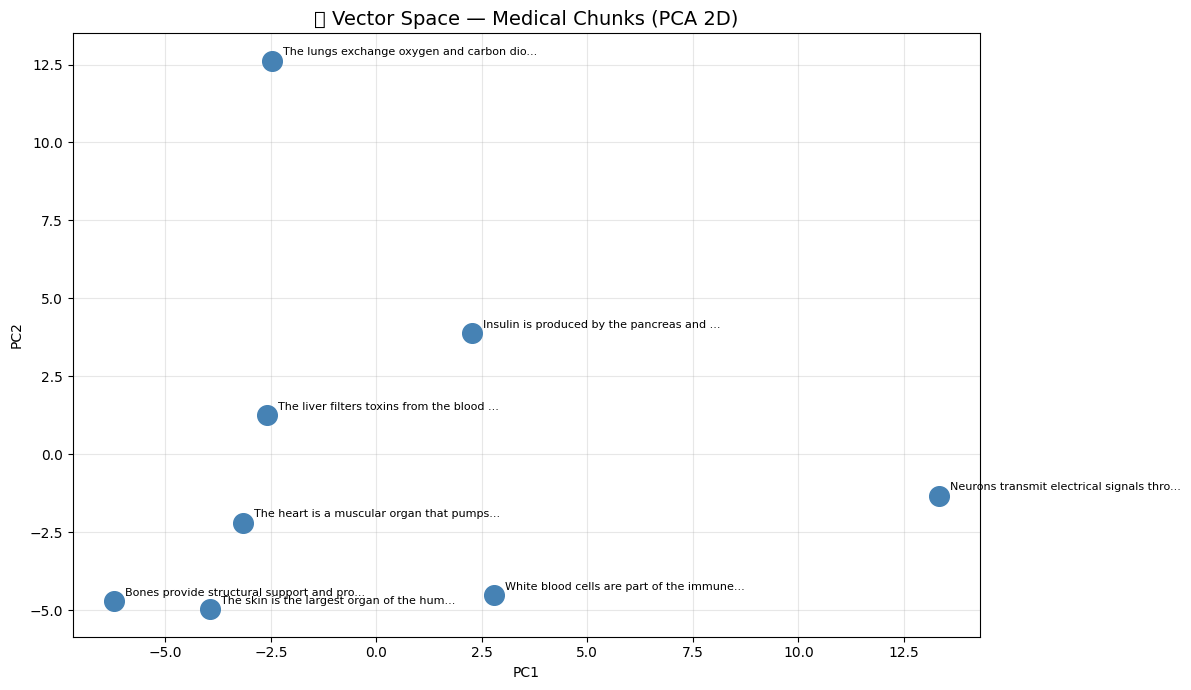

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Get all vectors and labels
texts   = [d['text'][:40] + '...' for d in sample_data]
vectors = np.array([embed(d['text']) for d in sample_data])

# Reduce to 2D
pca    = PCA(n_components=2)
coords = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(12, 7))
plt.scatter(coords[:, 0], coords[:, 1], c='steelblue', s=200, zorder=2)
for i, txt in enumerate(texts):
    plt.annotate(txt, (coords[i, 0], coords[i, 1]),
                 textcoords='offset points', xytext=(8, 4), fontsize=8)
plt.title('📊 Vector Space — Medical Chunks (PCA 2D)', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9️⃣ Collection Stats

In [14]:
collection = client.collections.get(COLLECTION_NAME)
count = collection.aggregate.over_all(total_count=True).total_count
print(f'📦 Total objects in Weaviate: {count}')
print(f'📐 Embedding dimensions: {len(embed("test"))}')
print(f'🗄️  Collection: {COLLECTION_NAME}')

📦 Total objects in Weaviate: 8
📐 Embedding dimensions: 768
🗄️  Collection: MedicalChunks


## 🔚 Close Connection

In [15]:
client.close()
print('✅ Connection closed')

✅ Connection closed


## ✅ Lab 1 Summary

| Step | What we did |
|------|-------------|
| Connect | Connected to Weaviate Cloud |
| Schema | Created a collection with HNSW index |
| Embed | Used Ollama nomic-embed-text locally |
| Insert | Stored vectors + metadata in Weaviate |
| Search | Queried by semantic similarity |
| Visualize | Plotted vector space in 2D |

➡️ **Next: Lab 2 — Chunking Strategies**